# Batch Docking: D-Site Binders vs TBXT Pocket D

Dock Boltz in-site binders against the TBXT-D pocket, rank by docking
score, then run full interaction analysis and 3D visualization for the top 3.

In [1]:
import pandas as pd
from tbxt_hackathon.docking import dock_batch, dock_single

## 1. Load candidates

In [2]:
POCKET_PDB = "../data/structures/TGT_TBXT_D_pocket.pdb"

candidates = pd.read_csv(
    "../data/binders/D/in-site-boltz.csv"
)
assert candidates.shape[0] > 0, "No candidates loaded"

smiles_list = candidates["Molecule"].tolist()
ids = candidates["Id"].tolist()
print(f"Loaded {len(smiles_list)} candidates")

Loaded 7 candidates


## 2. Batch docking (fast scoring)

3 conformers per compound, exhaustiveness=3, 1 pose each for speed.

In [3]:
batch_scores = dock_batch(
    smiles_list,
    POCKET_PDB,
    n_conformers=3,
    exhaustiveness=3,
    n_poses=1,
)
assert batch_scores.shape[0] == len(smiles_list)

batch_scores.insert(1, "id", ids)
batch_scores = batch_scores.sort_values("score").reset_index(drop=True)
print(f"Successfully docked: {(batch_scores['status'] == 'ok').sum()} / {len(batch_scores)}")
batch_scores.head(10).style.background_gradient(subset=["score"], cmap="RdYlGn_r")

Successfully docked: 7 / 7


,smiles,id,score,ligand_efficiency,n_heavy_atoms,mw,score_std,status
0,Clc1cccc(Oc2nnc(Cc3ccccc3)c3ccccc23)c1,SM-QZJTGDW5,-7.697000,0.307900,25,346.820000,0.054000,ok
1,O=C(Nc1cccc(OCc2ccccc2)c1)N1Cc2ccc(O)cc2C(O)C1,SM-68MRL1C4,-7.150000,0.246600,29,390.440000,0.201000,ok
2,N#Cc1ccc(Nc2ccc3c(CC(=O)O)noc3c2)cc1OCc1ccccc1,SM-BVFSTKQ9,-6.995000,0.233200,30,399.410000,0.138000,ok
3,COc1ccc(n2c(CO)nc3ccc(C(=O)O)nc32)cc1OCc1ccccc1,SM-Y7ALGPZQ,-6.852000,0.228400,30,405.410000,0.025000,ok
4,O=C(COc1cccc2ccccc12)Nc1cc(Cl)ccc1C(=O)O,SM-7S42XMFL,-6.763000,0.270500,25,355.780000,0.094000,ok
5,O=C(Nc1cccc(C(F)(F)F)c1)Nc1ccccc1C(=O)O,SM-173JKLGM,-6.398000,0.278200,23,324.260000,0.026000,ok
6,Cc1c(Nc2ccc(-n3cc(C(=O)O)nn3)cc2)cccc1OCc1ccccc1,SM-LWZQ4UEN,-6.141000,0.204700,30,400.440000,0.278000,ok


## 3. Score distribution

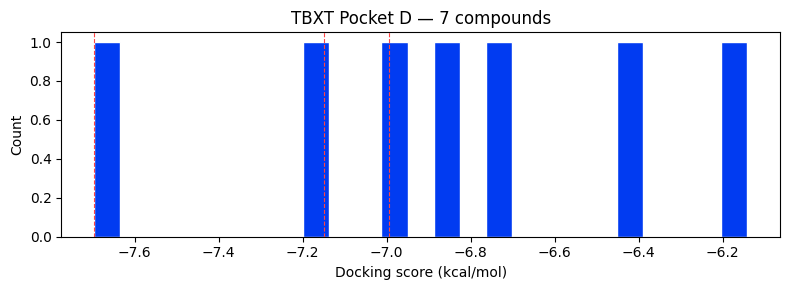

In [4]:
import matplotlib.pyplot as plt

ok = batch_scores[batch_scores["status"] == "ok"]

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ok["score"], bins=25, edgecolor="white", color="#013BF1")
ax.set_xlabel("Docking score (kcal/mol)")
ax.set_ylabel("Count")
ax.set_title(f"TBXT Pocket D — {len(ok)} compounds")

for i, row in ok.head(3).iterrows():
    ax.axvline(row["score"], color="#FF4444", ls="--", lw=0.8)

plt.tight_layout()
plt.show()

## 4. Full docking & 3D poses for top 3

Re-dock the top 3 with higher exhaustiveness and multiple poses for
detailed interaction analysis.

In [5]:
top3 = batch_scores[batch_scores["status"] == "ok"].head(3)

reports = []
for _, row in top3.iterrows():
    print(f"\nDocking {row['id']} ...")
    rpt = dock_single(
        row["smiles"],
        POCKET_PDB,
        n_conformers=3,
        exhaustiveness=32,
        n_poses=5,
    )
    reports.append((row["id"], rpt))
    print(rpt.summary())


Docking SM-QZJTGDW5 ...
Docking report: Clc1cccc(Oc2nnc(Cc3ccccc3)c3ccccc23)c1
  Best score:        -7.71 kcal/mol  (conformer 2, pose 0)
  Inter-molecular:   -9.52 kcal/mol
  Intra-molecular:   -0.63 kcal/mol
  Ligand efficiency: 0.309 kcal/mol/HA
  Heavy atoms:       25
  MW:                346.8
  Conformers run:    3
  Total poses:       15
  Score range:       -7.71 to -6.58 kcal/mol

  Best-pose interactions (11):
    hbond          ASP44    N     3.31 A  (protein_donor)
    hbond          TYR49    OH    3.18 A  (protein_donor)
    pi_stacking    TYR49    ring  4.77 A, angle=70  (edge_to_face)
    hydrophobic    LEU3     CD2   3.48 A
    hydrophobic    LEU43    CD2   3.50 A
    hydrophobic    ASP44    CG    3.62 A
    hydrophobic    TYR49    CE1   3.74 A
    hydrophobic    ILE133   CG2   3.62 A
    hydrophobic    ARG135   CB    3.58 A
    hydrophobic    MET142   CE    3.88 A
    hydrophobic    THR144   CG2   3.68 A

Docking SM-68MRL1C4 ...
Docking report: O=C(Nc1cccc(OCc2ccccc2)

### Rank 1

In [6]:
mol_id, rpt = reports[0]
print(f"{mol_id}: {rpt.score:.2f} kcal/mol  LE={rpt.ligand_efficiency:.3f}")
rpt.show_3d()

SM-QZJTGDW5: -7.71 kcal/mol  LE=0.309


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Rank 2

In [7]:
mol_id, rpt = reports[1]
print(f"{mol_id}: {rpt.score:.2f} kcal/mol  LE={rpt.ligand_efficiency:.3f}")
rpt.show_3d()

SM-68MRL1C4: -7.26 kcal/mol  LE=0.250


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Rank 3

In [8]:
mol_id, rpt = reports[2]
print(f"{mol_id}: {rpt.score:.2f} kcal/mol  LE={rpt.ligand_efficiency:.3f}")
rpt.show_3d()

SM-BVFSTKQ9: -7.00 kcal/mol  LE=0.233


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 5. Interaction comparison

In [9]:
rows = []
for mol_id, rpt in reports:
    bp = rpt.best_pose
    rows.append({
        "id": mol_id,
        "smiles": rpt.smiles,
        "score": rpt.score,
        "LE": rpt.ligand_efficiency,
        "HA": rpt.n_heavy_atoms,
        "inter": bp.inter_energy,
        "intra": bp.intra_energy,
        "hbonds": sum(1 for x in bp.interactions if x.type == "hbond"),
        "hydrophobic": sum(1 for x in bp.interactions if x.type == "hydrophobic"),
        "pi_stack": sum(1 for x in bp.interactions if x.type == "pi_stacking"),
        "salt_bridge": sum(1 for x in bp.interactions if x.type == "salt_bridge"),
        "total_interactions": len(bp.interactions),
        "key_residues": ", ".join(sorted({x.protein_residue for x in bp.interactions})),
    })

comparison = pd.DataFrame(rows)
comparison.style.background_gradient(subset=["score"], cmap="RdYlGn_r")

,id,smiles,score,LE,HA,inter,intra,hbonds,hydrophobic,pi_stack,salt_bridge,total_interactions,key_residues
0,SM-QZJTGDW5,Clc1cccc(Oc2nnc(Cc3ccccc3)c3ccccc23)c1,-7.715000,0.308600,25,-9.519000,-0.627000,2,8,1,0,11,"ARG135, ASP44, ILE133, LEU3, LEU43, MET142, THR144, TYR49"
1,SM-68MRL1C4,O=C(Nc1cccc(OCc2ccccc2)c1)N1Cc2ccc(O)cc2C(O)C1,-7.256000,0.250207,29,-9.801000,-0.673000,1,9,1,0,11,"ALA47, ARG135, ASP44, ILE133, LEU3, LEU43, MET142, THR144, TYR49"
2,SM-BVFSTKQ9,N#Cc1ccc(Nc2ccc3c(CC(=O)O)noc3c2)cc1OCc1ccccc1,-7.005000,0.233500,30,-10.076000,-1.317000,2,7,2,0,11,"ARG135, HIS146, ILE133, LEU3, LEU43, MET142, THR144, TYR49"


## 6. Save results

In [10]:
batch_scores.to_csv("../data/docking_scores_pocket_D.csv", index=False)
comparison.to_csv("../data/docking_top3_pocket_D.csv", index=False)
print("Saved to data/docking_scores_pocket_D.csv and data/docking_top3_pocket_D.csv")

Saved to data/docking_scores_pocket_D.csv and data/docking_top3_pocket_D.csv
